In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RAW_PATH = "../data/raw/"
PROCESSED_PATH = "../data/processed/"
VISUAL_PATH = "../visualization/"

In [2]:
df = pd.read_csv(RAW_PATH + "WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [3]:
df.columns.tolist()

['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'Over18',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [11]:
missing_values = pd.DataFrame({
    "column": df.columns,
    "missing_count": df.isnull().sum().values,
    "missing_percent": (df.isnull().sum().values / len(df)) * 100
})

missing_values[missing_values["missing_count"] > 0]

duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)
print("missing_values", missing_values)

Duplicate rows: 0
missing_values                       column  missing_count  missing_percent
0                        Age              0              0.0
1                  Attrition              0              0.0
2             BusinessTravel              0              0.0
3                  DailyRate              0              0.0
4                 Department              0              0.0
5           DistanceFromHome              0              0.0
6                  Education              0              0.0
7             EducationField              0              0.0
8              EmployeeCount              0              0.0
9             EmployeeNumber              0              0.0
10   EnvironmentSatisfaction              0              0.0
11                    Gender              0              0.0
12                HourlyRate              0              0.0
13            JobInvolvement              0              0.0
14                  JobLevel              0         

In [14]:
df["attrition_flag"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

df[["Attrition", "attrition_flag"]].head()

,Attrition,attrition_flag
0,Yes,1
1,No,0
2,Yes,1
3,No,0
4,No,0


In [15]:
df["age_group"] = pd.cut(
    df["Age"],
    bins=[18, 25, 35, 45, 55, 65],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65"],
    include_lowest=True
)

df["income_group"] = pd.qcut(
    df["MonthlyIncome"],
    q=4,
    labels=["Low Income", "Medium Income", "High Income", "Very High Income"]
)

df[["Age", "age_group", "MonthlyIncome", "income_group"]].head()

,Age,age_group,MonthlyIncome,income_group
0,41,36-45,5993,High Income
1,49,46-55,5130,High Income
2,37,36-45,2090,Low Income
3,33,26-35,2909,Low Income
4,27,26-35,3468,Medium Income


In [16]:
total_employees = df["EmployeeNumber"].nunique()
total_attrition = df["attrition_flag"].sum()
attrition_rate = total_attrition / total_employees

avg_age = df["Age"].mean()
avg_monthly_income = df["MonthlyIncome"].mean()
avg_years_at_company = df["YearsAtCompany"].mean()
avg_job_satisfaction = df["JobSatisfaction"].mean()
avg_work_life_balance = df["WorkLifeBalance"].mean()

kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Employees",
        "Total Attrition",
        "Attrition Rate",
        "Average Age",
        "Average Monthly Income",
        "Average Years at Company",
        "Average Job Satisfaction",
        "Average Work Life Balance"
    ],
    "Value": [
        total_employees,
        total_attrition,
        attrition_rate,
        avg_age,
        avg_monthly_income,
        avg_years_at_company,
        avg_job_satisfaction,
        avg_work_life_balance
    ]
})

kpi_summary

,Metric,Value
0,Total Employees,1470.000000
1,Total Attrition,237.000000
2,Attrition Rate,0.161224
3,Average Age,36.923810
4,Average Monthly Income,6502.931293
5,Average Years at Company,7.008163
6,Average Job Satisfaction,2.728571
7,Average Work Life Balance,2.761224


In [17]:
attrition_by_department = df.groupby("Department", as_index=False).agg({
    "EmployeeNumber": "nunique",
    "attrition_flag": "sum"
})

attrition_by_department = attrition_by_department.rename(columns={
    "EmployeeNumber": "total_employees",
    "attrition_flag": "total_attrition"
})

attrition_by_department["attrition_rate"] = (
    attrition_by_department["total_attrition"] /
    attrition_by_department["total_employees"]
)

attrition_by_department = attrition_by_department.sort_values(
    by="attrition_rate",
    ascending=False
)

attrition_by_department

,Department,total_employees,total_attrition,attrition_rate
2,Sales,446,92,0.206278
0,Human Resources,63,12,0.190476
1,Research & Development,961,133,0.138398


In [18]:
attrition_by_jobrole = df.groupby("JobRole", as_index=False).agg({
    "EmployeeNumber": "nunique",
    "attrition_flag": "sum"
})

attrition_by_jobrole = attrition_by_jobrole.rename(columns={
    "EmployeeNumber": "total_employees",
    "attrition_flag": "total_attrition"
})

attrition_by_jobrole["attrition_rate"] = (
    attrition_by_jobrole["total_attrition"] /
    attrition_by_jobrole["total_employees"]
)

attrition_by_jobrole = attrition_by_jobrole.sort_values(
    by="attrition_rate",
    ascending=False
)

attrition_by_jobrole

,JobRole,total_employees,total_attrition,attrition_rate
8,Sales Representative,83,33,0.397590
2,Laboratory Technician,259,62,0.239382
1,Human Resources,52,12,0.230769
7,Sales Executive,326,57,0.174847
6,Research Scientist,292,47,0.160959
4,Manufacturing Director,145,10,0.068966
0,Healthcare Representative,131,9,0.068702
3,Manager,102,5,0.049020
5,Research Director,80,2,0.025000


In [19]:
attrition_by_overtime = df.groupby("OverTime", as_index=False).agg({
    "EmployeeNumber": "nunique",
    "attrition_flag": "sum"
})

attrition_by_overtime = attrition_by_overtime.rename(columns={
    "EmployeeNumber": "total_employees",
    "attrition_flag": "total_attrition"
})

attrition_by_overtime["attrition_rate"] = (
    attrition_by_overtime["total_attrition"] /
    attrition_by_overtime["total_employees"]
)

attrition_by_overtime = attrition_by_overtime.sort_values(
    by="attrition_rate",
    ascending=False
)

attrition_by_overtime

,OverTime,total_employees,total_attrition,attrition_rate
1,Yes,416,127,0.305288
0,No,1054,110,0.104364


In [20]:
attrition_by_age_group = df.groupby("age_group", as_index=False).agg({
    "EmployeeNumber": "nunique",
    "attrition_flag": "sum"
})

attrition_by_age_group = attrition_by_age_group.rename(columns={
    "EmployeeNumber": "total_employees",
    "attrition_flag": "total_attrition"
})

attrition_by_age_group["attrition_rate"] = (
    attrition_by_age_group["total_attrition"] /
    attrition_by_age_group["total_employees"]
)

attrition_by_age_group

,age_group,total_employees,total_attrition,attrition_rate
0,18-25,123,44,0.357724
1,26-35,606,116,0.191419
2,36-45,468,43,0.091880
3,46-55,226,26,0.115044
4,56-65,47,8,0.170213


In [21]:
attrition_by_income_group = df.groupby("income_group", as_index=False).agg({
    "EmployeeNumber": "nunique",
    "attrition_flag": "sum"
})

attrition_by_income_group = attrition_by_income_group.rename(columns={
    "EmployeeNumber": "total_employees",
    "attrition_flag": "total_attrition"
})

attrition_by_income_group["attrition_rate"] = (
    attrition_by_income_group["total_attrition"] /
    attrition_by_income_group["total_employees"]
)

attrition_by_income_group

,income_group,total_employees,total_attrition,attrition_rate
0,Low Income,369,108,0.292683
1,Medium Income,366,52,0.142077
2,High Income,367,39,0.106267
3,Very High Income,368,38,0.103261


In [22]:
attrition_by_job_satisfaction = df.groupby("JobSatisfaction", as_index=False).agg({
    "EmployeeNumber": "nunique",
    "attrition_flag": "sum"
})

attrition_by_job_satisfaction = attrition_by_job_satisfaction.rename(columns={
    "EmployeeNumber": "total_employees",
    "attrition_flag": "total_attrition"
})

attrition_by_job_satisfaction["attrition_rate"] = (
    attrition_by_job_satisfaction["total_attrition"] /
    attrition_by_job_satisfaction["total_employees"]
)

attrition_by_job_satisfaction

,JobSatisfaction,total_employees,total_attrition,attrition_rate
0,1,289,66,0.228374
1,2,280,46,0.164286
2,3,442,73,0.165158
3,4,459,52,0.113290


In [23]:
attrition_by_work_life_balance = df.groupby("WorkLifeBalance", as_index=False).agg({
    "EmployeeNumber": "nunique",
    "attrition_flag": "sum"
})

attrition_by_work_life_balance = attrition_by_work_life_balance.rename(columns={
    "EmployeeNumber": "total_employees",
    "attrition_flag": "total_attrition"
})

attrition_by_work_life_balance["attrition_rate"] = (
    attrition_by_work_life_balance["total_attrition"] /
    attrition_by_work_life_balance["total_employees"]
)

attrition_by_work_life_balance

,WorkLifeBalance,total_employees,total_attrition,attrition_rate
0,1,80,25,0.312500
1,2,344,58,0.168605
2,3,893,127,0.142217
3,4,153,27,0.176471


In [24]:
def assign_risk_segment(row):
    if row["OverTime"] == "Yes" and row["JobSatisfaction"] <= 2 and row["WorkLifeBalance"] <= 2:
        return "High Risk"
    elif row["OverTime"] == "Yes" and (row["JobSatisfaction"] <= 2 or row["WorkLifeBalance"] <= 2):
        return "Medium Risk"
    elif row["JobSatisfaction"] <= 2 and row["WorkLifeBalance"] <= 2:
        return "Medium Risk"
    else:
        return "Low Risk"

df["risk_segment"] = df.apply(assign_risk_segment, axis=1)

risk_segment_summary = df.groupby("risk_segment", as_index=False).agg({
    "EmployeeNumber": "nunique",
    "attrition_flag": "sum",
    "MonthlyIncome": "mean",
    "Age": "mean",
    "YearsAtCompany": "mean"
})

risk_segment_summary = risk_segment_summary.rename(columns={
    "EmployeeNumber": "total_employees",
    "attrition_flag": "total_attrition",
    "MonthlyIncome": "avg_monthly_income",
    "Age": "avg_age",
    "YearsAtCompany": "avg_years_at_company"
})

risk_segment_summary["attrition_rate"] = (
    risk_segment_summary["total_attrition"] /
    risk_segment_summary["total_employees"]
)

risk_segment_summary = risk_segment_summary.sort_values(
    by="attrition_rate",
    ascending=False
)

risk_segment_summary

,risk_segment,total_employees,total_attrition,avg_monthly_income,avg_age,avg_years_at_company,attrition_rate
0,High Risk,39,16,6548.256410,39.205128,6.307692,0.410256
2,Medium Risk,316,83,6493.610759,37.063291,7.091772,0.262658
1,Low Risk,1115,138,6503.987444,36.804484,7.008969,0.123767


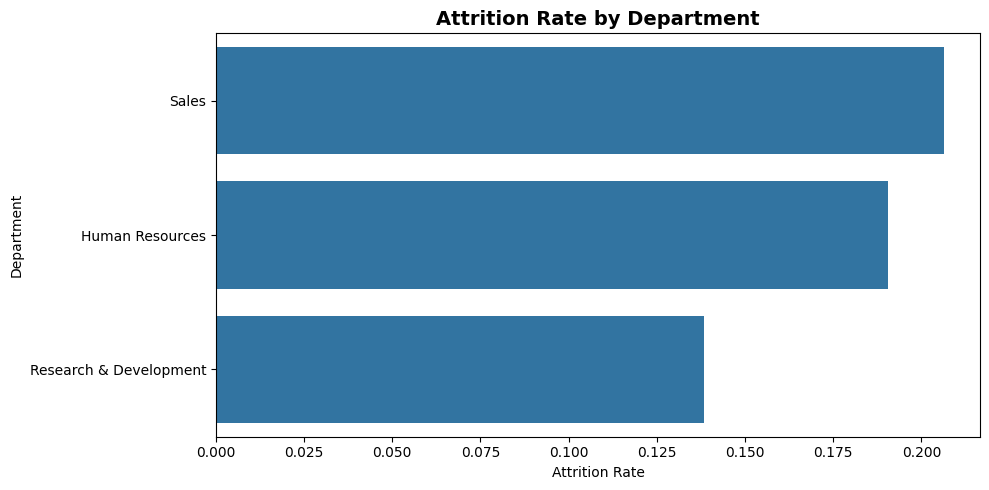

In [25]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=attrition_by_department,
    x="attrition_rate",
    y="Department"
)

plt.title("Attrition Rate by Department", fontsize=14, fontweight="bold")
plt.xlabel("Attrition Rate")
plt.ylabel("Department")
plt.tight_layout()

plt.savefig(VISUAL_PATH + "attrition_by_department.png", dpi=300)
plt.show()

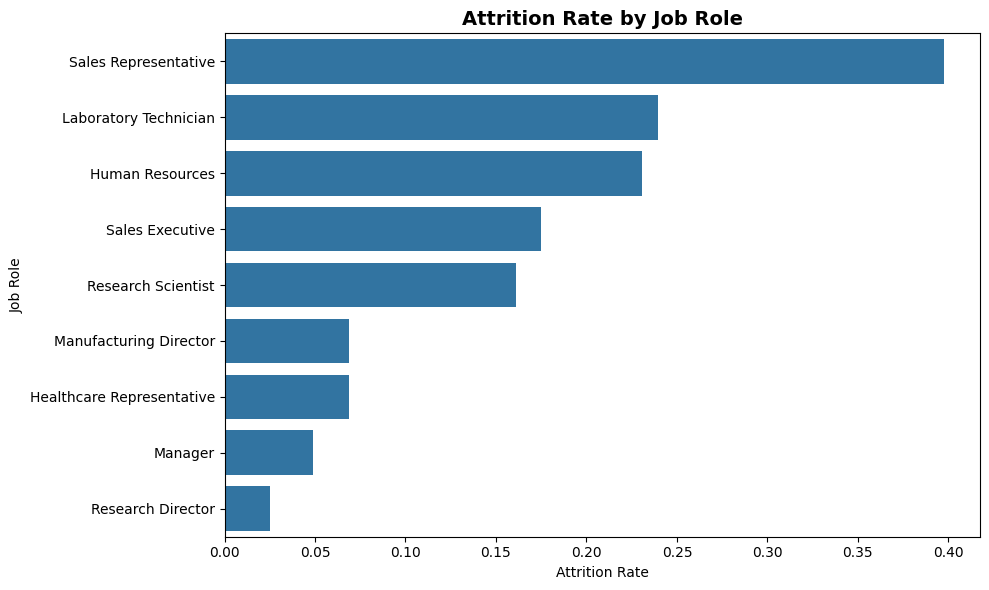

In [26]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=attrition_by_jobrole,
    x="attrition_rate",
    y="JobRole"
)

plt.title("Attrition Rate by Job Role", fontsize=14, fontweight="bold")
plt.xlabel("Attrition Rate")
plt.ylabel("Job Role")
plt.tight_layout()

plt.savefig(VISUAL_PATH + "attrition_by_jobrole.png", dpi=300)
plt.show()

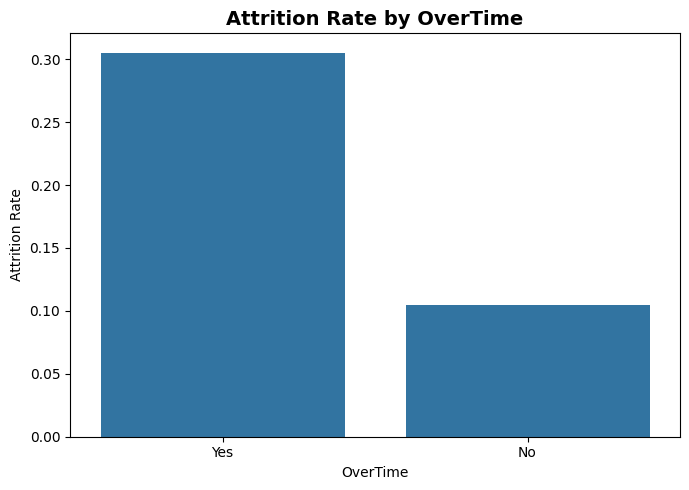

In [27]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=attrition_by_overtime,
    x="OverTime",
    y="attrition_rate"
)

plt.title("Attrition Rate by OverTime", fontsize=14, fontweight="bold")
plt.xlabel("OverTime")
plt.ylabel("Attrition Rate")
plt.tight_layout()

plt.savefig(VISUAL_PATH + "attrition_by_overtime.png", dpi=300)
plt.show()

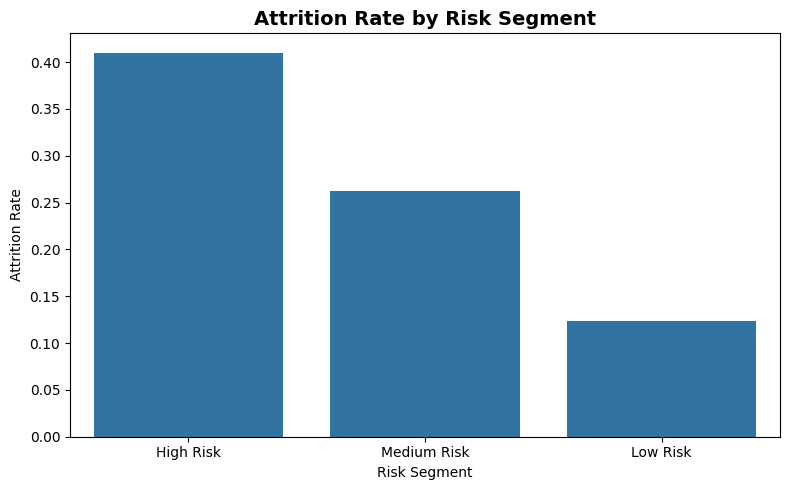

In [28]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=risk_segment_summary,
    x="risk_segment",
    y="attrition_rate"
)

plt.title("Attrition Rate by Risk Segment", fontsize=14, fontweight="bold")
plt.xlabel("Risk Segment")
plt.ylabel("Attrition Rate")
plt.tight_layout()

plt.savefig(VISUAL_PATH + "attrition_by_risk_segment.png", dpi=300)
plt.show()

In [29]:
df.to_csv(PROCESSED_PATH + "hr_attrition_cleaned.csv", index=False)

kpi_summary.to_csv(PROCESSED_PATH + "kpi_summary.csv", index=False)
attrition_by_department.to_csv(PROCESSED_PATH + "attrition_by_department.csv", index=False)
attrition_by_jobrole.to_csv(PROCESSED_PATH + "attrition_by_jobrole.csv", index=False)
attrition_by_overtime.to_csv(PROCESSED_PATH + "attrition_by_overtime.csv", index=False)
attrition_by_age_group.to_csv(PROCESSED_PATH + "attrition_by_age_group.csv", index=False)
attrition_by_income_group.to_csv(PROCESSED_PATH + "attrition_by_income_group.csv", index=False)
attrition_by_job_satisfaction.to_csv(PROCESSED_PATH + "attrition_by_job_satisfaction.csv", index=False)
attrition_by_work_life_balance.to_csv(PROCESSED_PATH + "attrition_by_work_life_balance.csv", index=False)
risk_segment_summary.to_csv(PROCESSED_PATH + "risk_segment_summary.csv", index=False)

print("Processed files saved successfully!")
print("Cleaned data:", df.shape)
print("KPI summary:", kpi_summary.shape)
print("Risk segment summary:", risk_segment_summary.shape)

Processed files saved successfully!
Cleaned data: (1470, 39)
KPI summary: (8, 2)
Risk segment summary: (3, 7)
